In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
from plot_utils import plot_results


In [2]:
action_spaces = [
    "joint-velocity",
    # "joint-torque",
    "cartesian_increment-position",
    "joint_increment-position",
]
prefix = "PandaPickCubeCartesianModified"
postfix="_prop-seed"
logs_dir = "../logs"
# resolve logsdir

logs_dir = os.path.abspath(logs_dir)

In [3]:
## List path of all event files in directory

# recursively list all event files under logs_dir
event_files = []
for root, _, files in os.walk(logs_dir):
    for f in files:
        if f.startswith("events.out.tfevents"):
            event_files.append(os.path.join(root, f))
event_files, len(event_files);

In [4]:
# group the runs
run_groups = {}

for action_space in action_spaces:
    run_groups[action_space] = []
    for ef in event_files:
        parent = os.path.basename(os.path.dirname(ef))
        if action_space in ef:
            run_groups[action_space].append(ef)

# deduplicate and sort each group
for k in run_groups:
    run_groups[k] = sorted(set(run_groups[k]))

# show counts per group
{k: len(v) for k, v in run_groups.items()}

{'joint-velocity': 10,
 'cartesian_increment-position': 10,
 'joint_increment-position': 10}

In [5]:
## Let's first plot results for one action space

tb_tags_list = [
    "episode/success",
    "episode/sum_reward",
    "episode/floor_collision",
    "episode/jerk"
]

In [6]:
axis_tag_names = {
    "episode/success": "Success Rate",
    "episode/sum_reward": "Episodic Return",
    "episode/floor_collision": "Floor Collisions",
    "episode/jerk": "Jerk",
}

In [7]:
legend_names = {
    "joint-velocity": r"$v$",
    "joint-torque": r"$\tau$",
    "cartesian_increment-position": r"$\delta x$",
    "joint_increment-position": r"$\delta q$",
}

generating plot


0it [00:00, ?it/s]

1it [00:11, 11.11s/it]

Processing tag 'episode/success' with 977 rows
20
PandaPickCubeCartesianModified-joint-velocity-_prop-seed-0    0.988235
PandaPickCubeCartesianModified-joint-velocity-_prop-seed-1    0.987059
PandaPickCubeCartesianModified-joint-velocity-_prop-seed-2    0.992353
PandaPickCubeCartesianModified-joint-velocity-_prop-seed-3    0.982353
PandaPickCubeCartesianModified-joint-velocity-_prop-seed-4    0.984706
PandaPickCubeCartesianModified-joint-velocity-_prop-seed-5    0.983529
PandaPickCubeCartesianModified-joint-velocity-_prop-seed-6    0.975882
PandaPickCubeCartesianModified-joint-velocity-_prop-seed-7    0.976471
PandaPickCubeCartesianModified-joint-velocity-_prop-seed-8    0.987647
PandaPickCubeCartesianModified-joint-velocity-_prop-seed-9    0.987647
dtype: float64
Processing tag 'episode/sum_reward' with 977 rows
20
PandaPickCubeCartesianModified-joint-velocity-_prop-seed-0    11.286584
PandaPickCubeCartesianModified-joint-velocity-_prop-seed-1    11.240436
PandaPickCubeCartesianModifi

2it [00:22, 11.13s/it]

Processing tag 'episode/success' with 980 rows
20
PandaPickCubeCartesianModified-cartesian_increment-position-_prop-seed-0    0.9925
PandaPickCubeCartesianModified-cartesian_increment-position-_prop-seed-1    0.9945
PandaPickCubeCartesianModified-cartesian_increment-position-_prop-seed-2    0.9955
PandaPickCubeCartesianModified-cartesian_increment-position-_prop-seed-3    0.9940
PandaPickCubeCartesianModified-cartesian_increment-position-_prop-seed-4    0.9885
PandaPickCubeCartesianModified-cartesian_increment-position-_prop-seed-5    0.9960
PandaPickCubeCartesianModified-cartesian_increment-position-_prop-seed-6    0.9895
PandaPickCubeCartesianModified-cartesian_increment-position-_prop-seed-7    0.9930
PandaPickCubeCartesianModified-cartesian_increment-position-_prop-seed-8    0.9945
PandaPickCubeCartesianModified-cartesian_increment-position-_prop-seed-9    0.9930
dtype: float64
Processing tag 'episode/sum_reward' with 980 rows
20
PandaPickCubeCartesianModified-cartesian_increment-p

3it [00:32, 10.97s/it]

Processing tag 'episode/success' with 980 rows
20
PandaPickCubeCartesianModified-joint_increment-position-_prop-seed-0    0.9870
PandaPickCubeCartesianModified-joint_increment-position-_prop-seed-1    0.9890
PandaPickCubeCartesianModified-joint_increment-position-_prop-seed-2    0.9920
PandaPickCubeCartesianModified-joint_increment-position-_prop-seed-3    0.9870
PandaPickCubeCartesianModified-joint_increment-position-_prop-seed-4    0.9955
PandaPickCubeCartesianModified-joint_increment-position-_prop-seed-5    0.9945
PandaPickCubeCartesianModified-joint_increment-position-_prop-seed-6    0.9865
PandaPickCubeCartesianModified-joint_increment-position-_prop-seed-7    0.9830
PandaPickCubeCartesianModified-joint_increment-position-_prop-seed-8    0.9900
PandaPickCubeCartesianModified-joint_increment-position-_prop-seed-9    0.9835
dtype: float64
Processing tag 'episode/sum_reward' with 980 rows
20
PandaPickCubeCartesianModified-joint_increment-position-_prop-seed-0    11.438905
PandaPickC

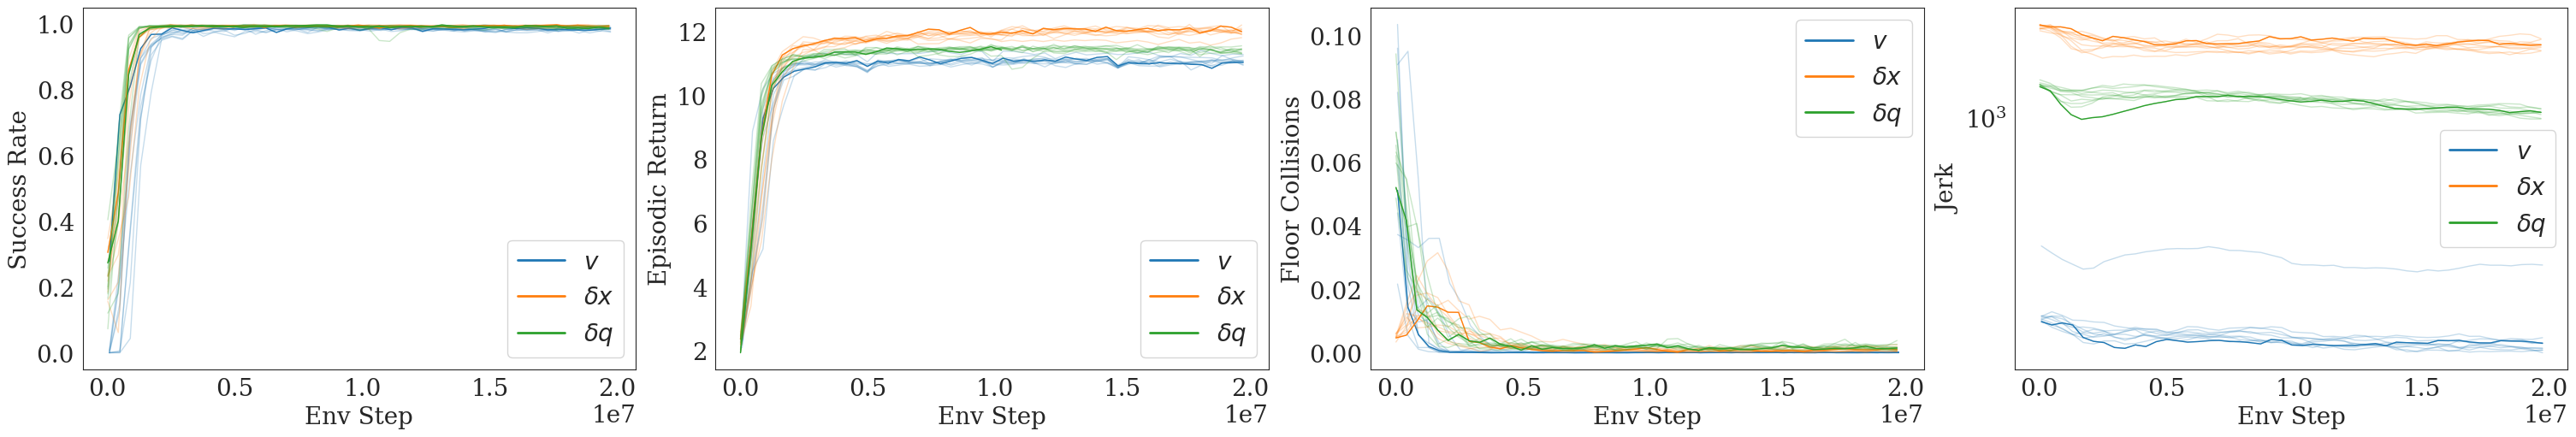

In [8]:
plot_results(run_groups, legend_names)